# Sentinel-5P TROPOMI – NO₂ Tropospheric Column – Jorf Lasfar Industrial Plume

This notebook downloads **Sentinel-5P TROPOMI Level 2 tropospheric NO₂** data from the
**Copernicus Data Space Ecosystem (CDSE)** and visualises the industrial NO₂ plume from  
**Jorf Lasfar** (Morocco, ~33.1 °N / 8.6 °W) — home to one of the world's largest phosphate
processing complexes (OCP Group), a coal power plant, and major fertiliser factories.


#### Outline
1. [Imports & helper functions](#setup)
2. [Define source & credentials](#source)
3. [Search for TROPOMI NO₂ files](#search)
4. [Download files](#download)
5. [Quick orbit overview](#orbit)
6. [Crop to Jorf Lasfar region](#crop)
7. [Visualise the NO₂ plume](#visualise)


## <a id='setup'></a>1 – Imports & helper functions


In [3]:
import glob
import getpass
import os

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Load helper functions from the local tropomi_utils.py
# (no ddeq install required – functions are extracted directly)
import sys
sys.path.insert(0, os.path.dirname(os.path.abspath("tropomi_utils.py")))

from tropomi_utils import (
    make_sources,
    get_bounding_box,
    list_files,
    Download,
    open_netCDF,
    reduce_dims_and_vars,
    crop_and_save,
    plot_orbit,
    plot_extent,
)


## <a id='source'></a>2 – Define source & credentials

Register for free at [dataspace.copernicus.eu](https://dataspace.copernicus.eu/) if you don't have an account.  
Set your credentials as environment variables **`CDSE_USER`** and **`CDSE_PASSWORD`**, or enter them interactively below.


In [4]:
# -----------------------------------------------------------------------
# Point source: Jorf Lasfar industrial complex, Morocco
# -----------------------------------------------------------------------
sources = make_sources(
    name="Jorf_Lasfar",
    lon=-8.638,
    lat=33.103,
    diameter=50000,  # 50 km search radius
)
print(sources)

# -----------------------------------------------------------------------
# CDSE credentials (set env vars or enter interactively)
# -----------------------------------------------------------------------
username = os.environ.get("CDSE_USER", "") or input("Copernicus Dataspace username (email): ")
password = os.environ.get("CDSE_PASSWORD", "") or getpass.getpass("Copernicus Dataspace password: ")

# Storage paths
data_path_raw     = os.path.join("data", "S5P_raw")
data_path_cropped = os.path.join("data", "S5P_cropped")
os.makedirs(data_path_raw,     exist_ok=True)
os.makedirs(data_path_cropped, exist_ok=True)


<xarray.Dataset> Size: 112B
Dimensions:   (source: 1)
Coordinates:
  * source    (source) <U11 44B 'Jorf_Lasfar'
Data variables:
    lon       (source) float64 8B -8.638
    lat       (source) float64 8B 33.1
    diameter  (source) int64 8B 50000
    label     (source) <U11 44B 'Jorf_Lasfar'


## <a id='search'></a>3 – Search for TROPOMI NO₂ files over Jorf Lasfar

`list_files()` queries the CDSE OData catalogue.  
Adjust `start_date` / `end_date` to target a different event.


In [5]:
# -----------------------------------------------------------------------
# Search parameters – adjust the date range to target a specific event.
# -----------------------------------------------------------------------
start_date = "2024-08-20"
end_date   = "2024-08-22"

# Bounding box centred on Jorf Lasfar with a 300 km radius
west_lon, east_lon, south_lat, north_lat = get_bounding_box(
    sources.sel(source="Jorf_Lasfar")["lon"].item(),
    sources.sel(source="Jorf_Lasfar")["lat"].item(),
    distance=300e3,     # 300 km
)

ids, filenames = list_files(
    west_lon, east_lon, south_lat, north_lat,
    start_date=start_date,
    end_date=end_date,
    product_abbreviation="L2__NO2___",
    latency="OFFL",
    level="L2",
    orbit="-",
)

print(f"Found {len(ids)} file(s):")
for fn in filenames:
    print(" ", fn)


Found 6 file(s):
  S5P_OFFL_L2__NO2____20240820T120900_20240820T135029_35513_03_020600_20240822T043300.nc
  S5P_OFFL_L2__NO2____20240820T135029_20240820T153159_35514_03_020600_20240822T055041.nc
  S5P_OFFL_L2__NO2____20240821T114951_20240821T133121_35527_03_020600_20240823T041132.nc
  S5P_OFFL_L2__NO2____20240821T133121_20240821T151250_35528_03_020600_20240823T053940.nc
  S5P_OFFL_L2__NO2____20240822T113043_20240822T131212_35541_03_020600_20240824T035056.nc
  S5P_OFFL_L2__NO2____20240822T131212_20240822T145342_35542_03_020600_20240824T052832.nc


In [6]:
## <a id='download'></a>4 – Download files

Files are saved to `data/S5P_raw/`.  
Already-downloaded files are skipped automatically.


SyntaxError: invalid syntax (2125423547.py, line 3)

In [7]:
downloader = Download(data_path_raw, username, password)
downloader.download_files(ids, filenames)


Already downloaded: S5P_OFFL_L2__NO2____20240820T120900_20240820T135029_35513_03_020600_20240822T043300.nc
Already downloaded: S5P_OFFL_L2__NO2____20240820T135029_20240820T153159_35514_03_020600_20240822T055041.nc
Already downloaded: S5P_OFFL_L2__NO2____20240821T114951_20240821T133121_35527_03_020600_20240823T041132.nc
Already downloaded: S5P_OFFL_L2__NO2____20240821T133121_20240821T151250_35528_03_020600_20240823T053940.nc
Already downloaded: S5P_OFFL_L2__NO2____20240822T113043_20240822T131212_35541_03_020600_20240824T035056.nc
Already downloaded: S5P_OFFL_L2__NO2____20240822T131212_20240822T145342_35542_03_020600_20240824T052832.nc


## <a id='orbit'></a>5 – Quick orbit overview

`plot_orbit()` shows the full swath to check coverage before cropping.


In [8]:
# List all downloaded NO2 files
all_files = sorted(
    [os.path.basename(f) for f in glob.glob(os.path.join(data_path_raw, "*NO2*.nc"))]
)
print(f"Downloaded files ({len(all_files)}):")
for f in all_files:
    print(" ", f)


Downloaded files (6):
  S5P_OFFL_L2__NO2____20240820T120900_20240820T135029_35513_03_020600_20240822T043300.nc
  S5P_OFFL_L2__NO2____20240820T135029_20240820T153159_35514_03_020600_20240822T055041.nc
  S5P_OFFL_L2__NO2____20240821T114951_20240821T133121_35527_03_020600_20240823T041132.nc
  S5P_OFFL_L2__NO2____20240821T133121_20240821T151250_35528_03_020600_20240823T053940.nc
  S5P_OFFL_L2__NO2____20240822T113043_20240822T131212_35541_03_020600_20240824T035056.nc
  S5P_OFFL_L2__NO2____20240822T131212_20240822T145342_35542_03_020600_20240824T052832.nc


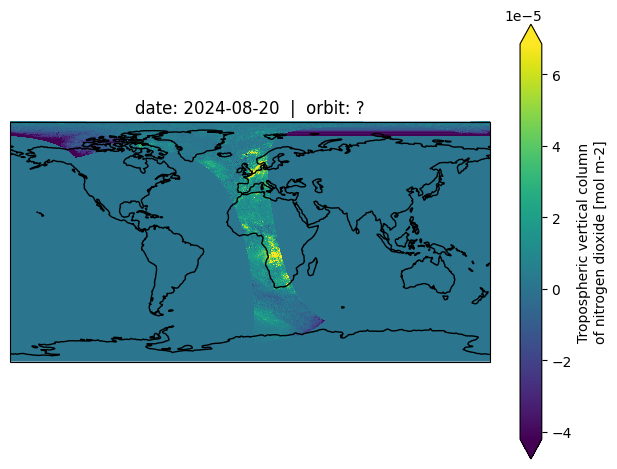

In [9]:
# Plot full orbit for the first file
plot_orbit(all_files[0], path=data_path_raw)
plt.show()


In [10]:
## <a id='crop'></a>6 – Crop to Jorf Lasfar region

`crop_and_save()` crops each orbit to a 300 km radius around the source
and saves the result to `data/S5P_cropped/`.  
Quality filtering (qa_value ≥ 0.75) is applied automatically during plotting.


SyntaxError: invalid character '≥' (U+2265) (404691373.py, line 5)

In [11]:
crop_and_save(
    all_files,
    sources.sel(source=["Jorf_Lasfar"]),
    distance=300e3,   # 300 km radius
    delete=False,
    path_open=data_path_raw,
    path_save=data_path_cropped,
)


Saved: data/S5P_cropped/Jorf_Lasfar_S5P_OFFL_L2__NO2____20240820T120900_20240820T135029_35513_03_020600_20240822T043300.nc
Saved: data/S5P_cropped/Jorf_Lasfar_S5P_OFFL_L2__NO2____20240820T135029_20240820T153159_35514_03_020600_20240822T055041.nc
Saved: data/S5P_cropped/Jorf_Lasfar_S5P_OFFL_L2__NO2____20240821T114951_20240821T133121_35527_03_020600_20240823T041132.nc
Saved: data/S5P_cropped/Jorf_Lasfar_S5P_OFFL_L2__NO2____20240821T133121_20240821T151250_35528_03_020600_20240823T053940.nc
Saved: data/S5P_cropped/Jorf_Lasfar_S5P_OFFL_L2__NO2____20240822T113043_20240822T131212_35541_03_020600_20240824T035056.nc
Saved: data/S5P_cropped/Jorf_Lasfar_S5P_OFFL_L2__NO2____20240822T131212_20240822T145342_35542_03_020600_20240824T052832.nc



## <a id='visualise'></a>7 – Visualise the NO₂ plume

`plot_extent()` maps the tropospheric NO₂ column for each cropped orbit.  
Pixels with qa_value ≤ 0.75 are masked automatically.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


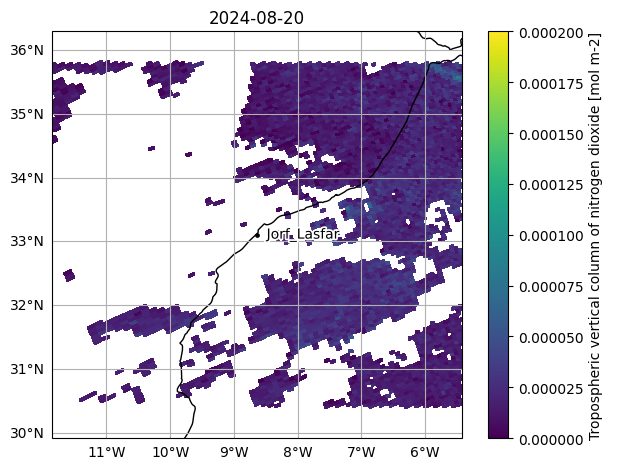

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


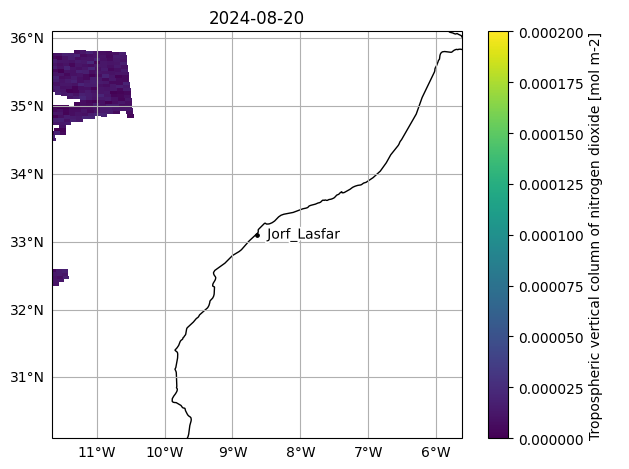

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


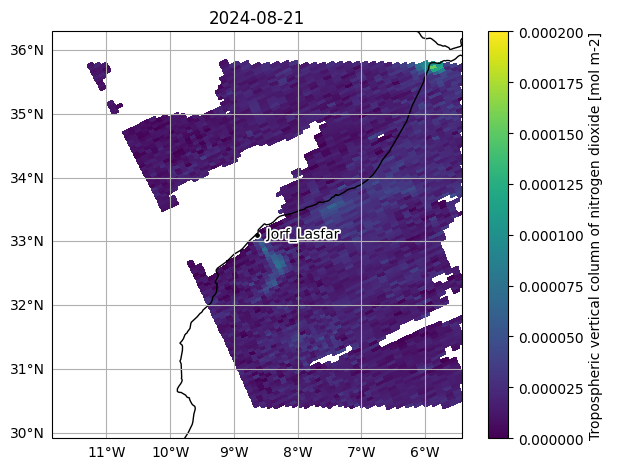

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


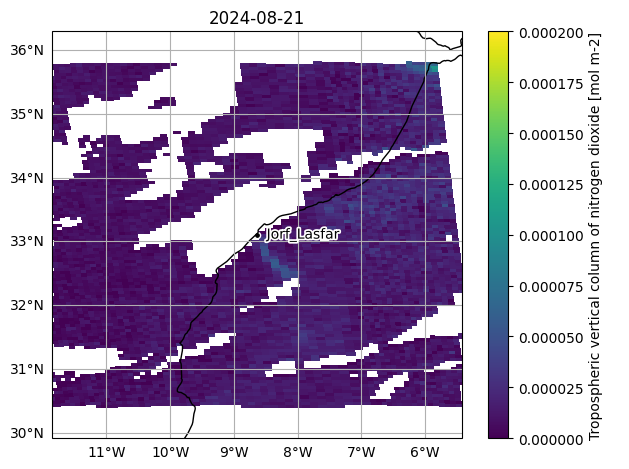

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


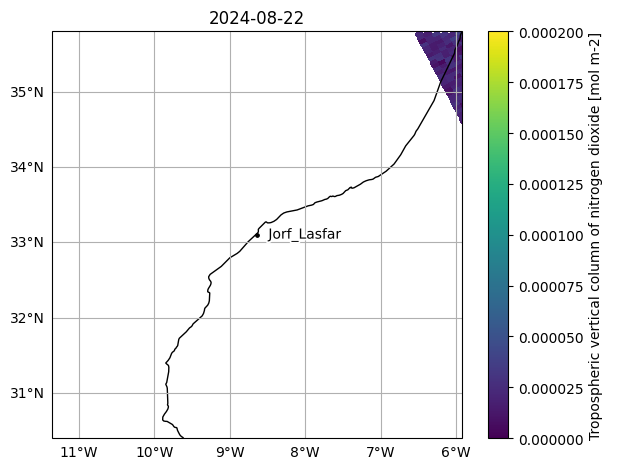

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


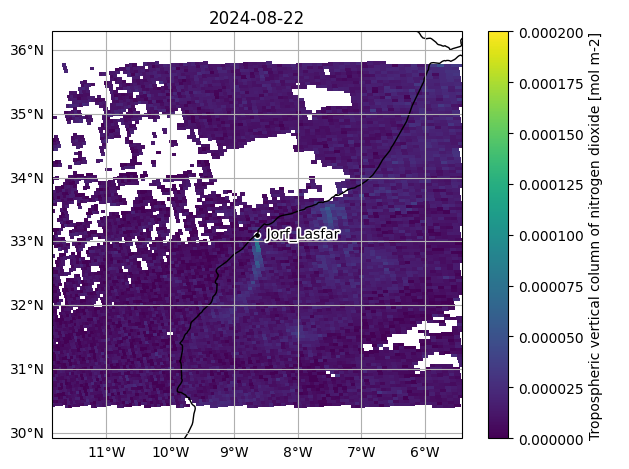

In [12]:
for filename in all_files:
    cropped_path = os.path.join(data_path_cropped, f"Jorf_Lasfar_{filename}")
    if not os.path.exists(cropped_path):
        print(f"No cropped file found for {filename} – skipping.")
        continue

    data_S5p = xr.open_dataset(cropped_path)

    fig = plot_extent(
        data_S5p,
        var="nitrogendioxide_tropospheric_column",
        sources=sources,
        vmin=0,
        vmax=200e-6,     # mol m-2; ~130 µmol m-2
        zoom=True,
        qa=True,
    )
    plt.tight_layout()
    plt.show()


---
## Notes

- **Jorf Lasfar** hosts one of the world's largest phosphate processing complexes (OCP Group),
  a coal power plant (Jorf Lasfar Energy), and several fertiliser factories — all significant NO₂ sources.
- The TROPOMI swath width is ~2600 km; revisit time is ~1 day at mid-latitudes.
- Prevailing Atlantic trade winds typically push the NO₂ plume **eastward** toward the Atlas Mountains.
- `qa_value ≥ 0.75` is the recommended threshold for tropospheric NO₂
  (cloud radiance fraction < 0.5, no snow/ice, no problematic retrievals).

### Helper functions (`tropomi_utils.py`)
| Function | Purpose |
|---|---|
| `make_sources(name, lon, lat)` | Create a ddeq-compatible sources Dataset |
| `get_bounding_box(lon, lat, dist)` | Compute a lon/lat bounding box |
| `list_files(...)` | Query CDSE OData for TROPOMI file IDs |
| `Download(path, user, pw)` | Download files via CDSE OAuth2 |
| `open_netCDF(filename, path)` | Merge PRODUCT + SUPPORT_DATA groups |
| `reduce_dims_and_vars(ds)` | Drop unneeded variables/dimensions |
| `crop_and_save(files, sources, dist)` | Crop orbits to a source region and save |
| `plot_orbit(filename, path)` | Quick full-swath overview plot |
| `plot_extent(ds, var, sources)` | Map plot of a cropped scene |

### Suggested further steps
- Change `start_date` / `end_date` to explore different days and seasonal variability.
- Load multiple cropped files with `xr.open_mfdataset()` and compute a monthly average.
- Compare weekday vs. weekend columns to separate industrial from traffic contributions.
